================================================
EDA PART 2: Data Quality & Annotation Reliability
================================================
Purpose:
  - Validate pixel-level annotation reliability
  - Detect noisy or structurally inconsistent samples


**[Cell 1] Imports & setup**

In [83]:
import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations

IMAGE_ROOT = "/data/ephemeral/home/data/train/DCM"
LABEL_ROOT = "/data/ephemeral/home/data/train/outputs_json"

CLASSES = [
    'finger-1','finger-2','finger-3','finger-4','finger-5',
    'finger-6','finger-7','finger-8','finger-9','finger-10',
    'finger-11','finger-12','finger-13','finger-14','finger-15',
    'finger-16','finger-17','finger-18','finger-19',
    'Trapezium','Trapezoid','Capitate','Hamate',
    'Scaphoid','Lunate','Triquetrum','Pisiform',
    'Radius','Ulna'
]

**[Cell 2] Pixel count per class per image**

In [84]:
pixel_records = []
mask_count_per_image = []

for root, _, files in tqdm(list(os.walk(LABEL_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        # 상대경로: IDxxx/filename.json
        rel_json_path = os.path.relpath(json_path, LABEL_ROOT)

        class_pixel_counts = {c: 0 for c in CLASSES}

        for ann in anns:
            pts = np.array(ann["points"])
            canvas = np.zeros((2048, 2048), np.uint8)
            cv2.fillPoly(canvas, [pts], 1)
            class_pixel_counts[ann["label"]] += canvas.sum()

        mask_count_per_image.append(
            sum(v > 0 for v in class_pixel_counts.values())
        )

        for c, v in class_pixel_counts.items():
            if v > 0:
                pixel_records.append({
                    "image": rel_json_path,   # ID001/xxx.json
                    "class": c,
                    "pixels": v
                })

pixel_df = pd.DataFrame(pixel_records)
print("Total non-empty masks:", len(pixel_df))

100%|██████████| 401/401 [01:13<00:00,  5.47it/s]


Total non-empty masks: 23200


**[Cell 3] Pixel distribution per class**

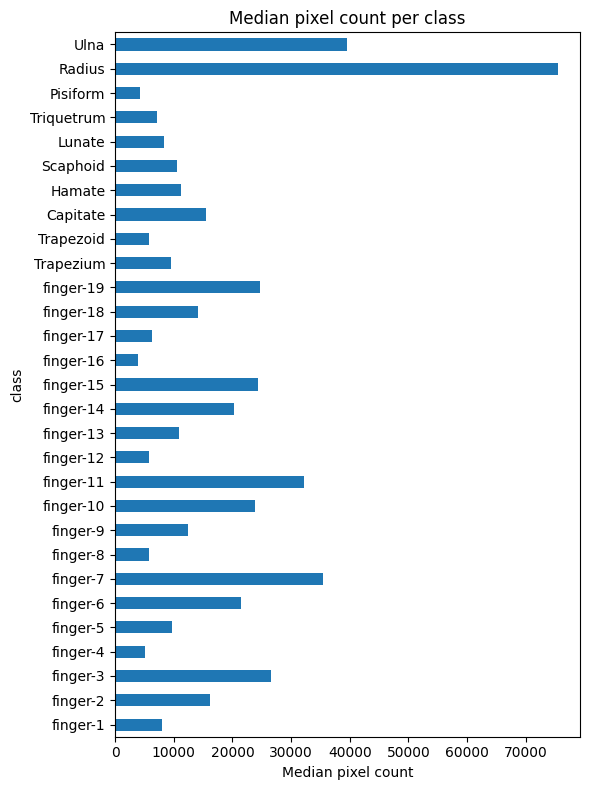

In [85]:
plt.figure(figsize=(6, 8))
pixel_df.groupby("class")["pixels"].median().reindex(CLASSES).plot(kind="barh")
plt.xlabel("Median pixel count")
plt.title("Median pixel count per class")
plt.tight_layout()
plt.show()

**[Cell 4] Low-pixel outlier detection (noise candidates)**

In [86]:
pixel_df["low_pixel_threshold"] = (
    pixel_df.groupby("class")["pixels"]
    .transform(lambda x: x.quantile(0.05))
)

outliers = pixel_df[pixel_df["pixels"] < pixel_df["low_pixel_threshold"]]
print(f"Potential noisy masks: {len(outliers)}")
outliers.head()

Potential noisy masks: 1158


,image,class,pixels,low_pixel_threshold
259,ID382/image1665453880555.json,Radius,56649,59670.1
260,ID382/image1665453880555.json,Ulna,29125,29395.0
422,ID286/image1664156819527.json,finger-17,4581,4733.6
466,ID081/image1661737462468.json,finger-3,21138,21256.7
468,ID081/image1661737462468.json,finger-5,7652,7984.4


**[Cell 5] Image-level mask count sanity check**

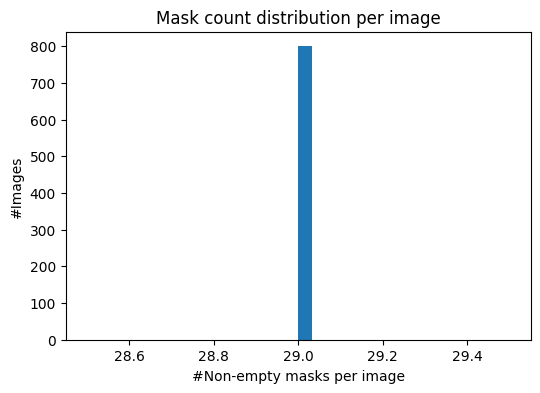

In [87]:
plt.figure(figsize=(6, 4))
plt.hist(mask_count_per_image, bins=30)
plt.xlabel("#Non-empty masks per image")
plt.ylabel("#Images")
plt.title("Mask count distribution per image")
plt.show()

**[Cell 6] Boundary adjacency analysis**

In [88]:
boundary_pairs = {}

for root, _, files in tqdm(list(os.walk(LABEL_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        masks = {}
        for ann in anns:
            pts = np.array(ann["points"])
            canvas = np.zeros((2048, 2048), np.uint8)
            cv2.fillPoly(canvas, [pts], 1)
            masks[ann["label"]] = canvas

        for c1, c2 in combinations(masks.keys(), 2):
            dilated = cv2.dilate(masks[c1], np.ones((3, 3), np.uint8))
            if np.any(dilated & masks[c2]):
                boundary_pairs[(c1, c2)] = boundary_pairs.get((c1, c2), 0) + 1

100%|██████████| 401/401 [12:22<00:00,  1.85s/it]


**[Cell 7] Boundary adjacency visualization (Top-K)**

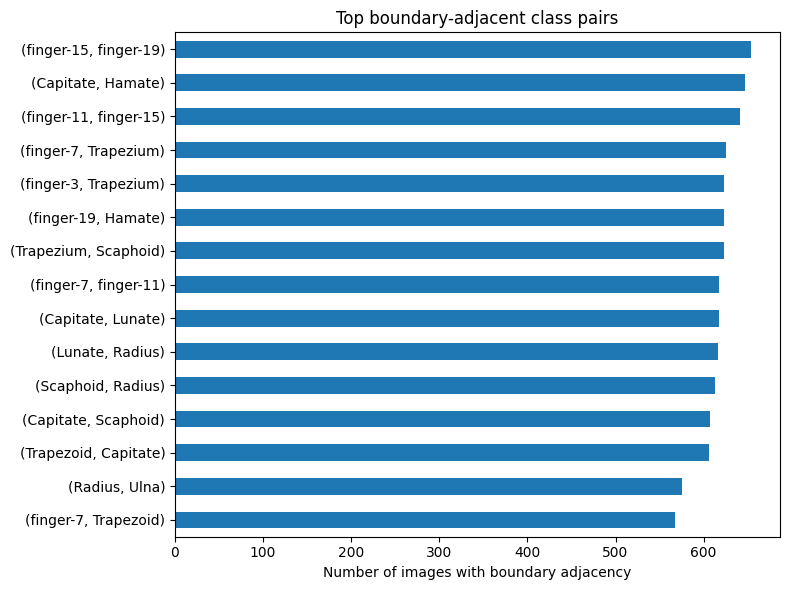

In [89]:
boundary_series = pd.Series(boundary_pairs).sort_values(ascending=False)

TOP_K = 15
topk = boundary_series.head(TOP_K)

plt.figure(figsize=(8, 6))
topk.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Number of images with boundary adjacency")
plt.title("Top boundary-adjacent class pairs")
plt.tight_layout()
plt.show()


**[Cell 8] Visualize suspicious low-pixel sample (image-level)**

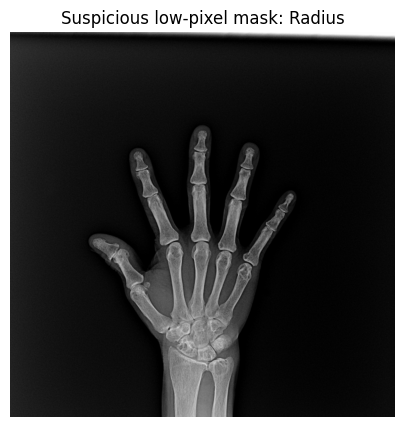

In [90]:
if len(outliers) > 0:
    sample = outliers.iloc[0]

    # IDxxx/filename.json → IDxxx/filename.png
    img_rel_path = sample["image"].replace(".json", ".png")
    img_path = os.path.join(IMAGE_ROOT, img_rel_path)

    img = cv2.imread(img_path)
    if img is None:
        print("Image not found:", img_path)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Suspicious low-pixel mask: {sample['class']}")
        plt.show()

# overlap check

**[Cell 1] Pixel-level class overlap analysis**

In [91]:
overlap_stats = []

for root, _, files in tqdm(list(os.walk(LABEL_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        # 모든 클래스 mask 쌓기
        masks = []
        for ann in anns:
            canvas = np.zeros((2048, 2048), np.uint8)
            pts = np.array(ann["points"], dtype=np.int32)
            cv2.fillPoly(canvas, [pts], 1)
            masks.append(canvas)

        if len(masks) == 0:
            continue

        stack = np.stack(masks, axis=0)   # (num_cls, H, W)
        overlap_count = stack.sum(axis=0) # (H, W)

        num_overlap_pixels = np.sum(overlap_count >= 2)

        overlap_stats.append({
            "image": os.path.relpath(json_path, LABEL_ROOT),
            "overlap_pixels": int(num_overlap_pixels)
        })

overlap_df = pd.DataFrame(overlap_stats)
overlap_df.describe()


100%|██████████| 401/401 [03:38<00:00,  1.84it/s]


,overlap_pixels
count,800.000000
mean,19684.727500
std,5090.612735
min,8111.000000
25%,16037.500000
50%,19039.500000
75%,22737.000000
max,39090.000000


**[Cell 2] Distribution of overlap pixels**

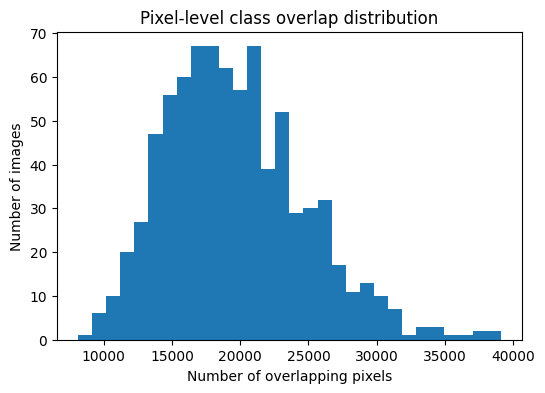

In [92]:
plt.figure(figsize=(6, 4))
plt.hist(overlap_df["overlap_pixels"], bins=30)
plt.xlabel("Number of overlapping pixels")
plt.ylabel("Number of images")
plt.title("Pixel-level class overlap distribution")
plt.show()


**[Cell 3] Pixel-level class overlap pairs**

In [ ]:
from itertools import combinations
from collections import Counter

overlap_pair_counter = Counter()

for root, _, files in tqdm(list(os.walk(LABEL_ROOT))):
    for f in files:
        if not f.endswith(".json"):
            continue

        json_path = os.path.join(root, f)
        with open(json_path) as fp:
            anns = json.load(fp)["annotations"]

        # 클래스별 mask 생성
        class_masks = {}
        for ann in anns:
            label = ann["label"]
            canvas = np.zeros((2048, 2048), np.uint8)
            pts = np.array(ann["points"], dtype=np.int32)
            cv2.fillPoly(canvas, [pts], 1)
            class_masks[label] = canvas

        # 클래스 쌍별 overlap 계산
        for c1, c2 in combinations(class_masks.keys(), 2):
            overlap_pixels = np.sum(
                (class_masks[c1] == 1) & (class_masks[c2] == 1)
            )

            if overlap_pixels > 0:
                overlap_pair_counter[(c1, c2)] += overlap_pixels


100%|██████████| 401/401 [23:06<00:00,  3.46s/it]


In [94]:
overlap_pair_df = (
    pd.DataFrame(
        [(k[0], k[1], v) for k, v in overlap_pair_counter.items()],
        columns=["class_1", "class_2", "overlap_pixels"]
    )
    .sort_values("overlap_pixels", ascending=False)
    .reset_index(drop=True)
)

overlap_pair_df.head(10)


,class_1,class_2,overlap_pixels
0,Pisiform,Triquetrum,1780156
1,Trapezium,Trapezoid,1355340
2,Triquetrum,Pisiform,1058262
3,Capitate,Scaphoid,868542
4,finger-19,Hamate,853244
5,Capitate,Hamate,815776
6,Lunate,Radius,758116
7,Scaphoid,Radius,718128
8,Capitate,Lunate,711108
9,finger-15,finger-19,596779


In [95]:
# 클래스 이름 → index 매핑
cls2idx = {c: i for i, c in enumerate(CLASSES)}
n_cls = len(CLASSES)

overlap_matrix = np.zeros((n_cls, n_cls), dtype=np.int64)


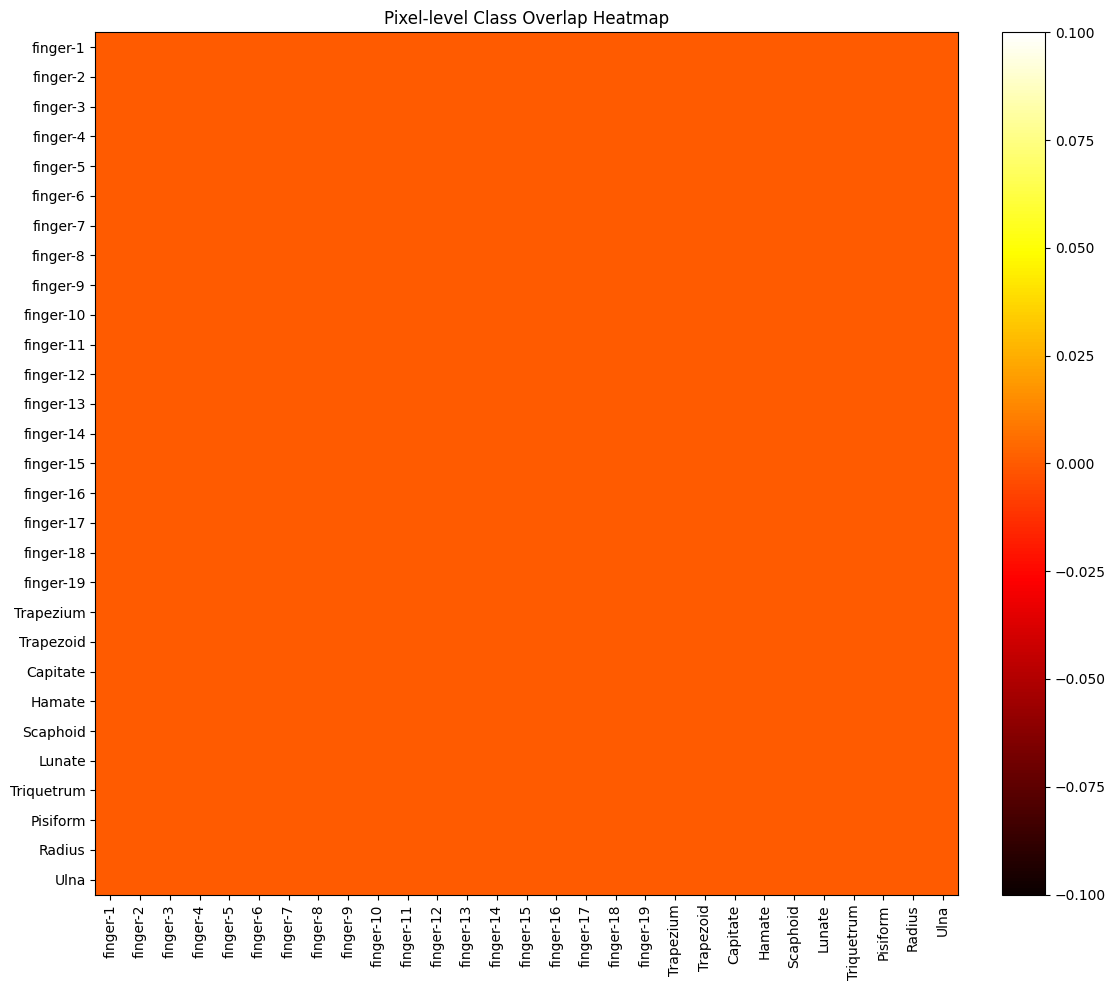

In [96]:
plt.figure(figsize=(12, 10))
im = plt.imshow(overlap_matrix, cmap="hot")

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(n_cls), CLASSES, rotation=90)
plt.yticks(range(n_cls), CLASSES)

plt.title("Pixel-level Class Overlap Heatmap")
plt.tight_layout()
plt.show()


In [97]:
for _, row in overlap_pair_df.iterrows():
    i = cls2idx[row["class_1"]]
    j = cls2idx[row["class_2"]]
    v = row["overlap_pixels"]

    overlap_matrix[i, j] += v
    overlap_matrix[j, i] += v  # 대칭


In [100]:
def show_overlap(idx, overlap_df_sorted=None, alpha=0.6):
    if overlap_df_sorted is None:
        raise ValueError("overlap_df_sorted must be provided")

    if idx < 0 or idx >= len(overlap_df_sorted):
        print("Index out of range")
        return

    row = overlap_df_sorted.iloc[idx]
    json_rel_path = row["image"]

    json_path = os.path.join(LABEL_ROOT, json_rel_path)
    img_path = os.path.join(
        IMAGE_ROOT,
        json_rel_path.replace(".json", ".png")
    )

    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with open(json_path) as fp:
        anns = json.load(fp)["annotations"]

    masks = []
    for ann in anns:
        canvas = np.zeros(img.shape[:2], np.uint8)
        pts = np.array(ann["points"], dtype=np.int32)
        cv2.fillPoly(canvas, [pts], 1)
        masks.append(canvas)

    stack = np.stack(masks, axis=0)
    overlap_mask = (stack.sum(axis=0) >= 2)

    overlay = img.copy()
    overlay[overlap_mask] = [255, 0, 255]

    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Overlap pixels = {row['overlap_pixels']}")
    axes[1].axis("off")

    plt.suptitle(json_rel_path)
    plt.show()


In [101]:
# overlap이 많은 순서로 정렬
overlap_df_sorted = overlap_df.sort_values(
    "overlap_pixels", ascending=False
).reset_index(drop=True)


# overlap이 가장 많은 이미지 보기
show_overlap(0)

# 그 다음 몇 개
show_overlap(1)
show_overlap(2)


ValueError: overlap_df_sorted must be provided

## 이상치 이미지 확인하기

**[Cell 1] 이상치 목록 고정 + 인덱스 확인**

In [ ]:
outliers_sorted = outliers.sort_values("pixels").reset_index(drop=True)

print(f"Total suspicious samples: {len(outliers_sorted)}")
outliers_sorted.head()

**[Cell 2] 단일 샘플 시각화 함수 (번호로 접근)**

In [ ]:
def show_outlier(idx, alpha=0.5):
    if idx < 0 or idx >= len(outliers_sorted):
        print("Index out of range")
        return

    row = outliers_sorted.iloc[idx]

    json_rel_path = row["image"]
    target_class = row["class"]
    pixel_count = row["pixels"]

    json_path = os.path.join(LABEL_ROOT, json_rel_path)
    img_path = os.path.join(
        IMAGE_ROOT,
        json_rel_path.replace(".json", ".png")
    )

    print(f"[#{idx}] {json_rel_path}")
    print(f"Class: {target_class}, Pixels: {pixel_count}")

    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with open(json_path) as fp:
        anns = json.load(fp)["annotations"]

    # overlay 생성
    overlay = img.copy()
    for ann in anns:
        if ann["label"] == target_class:
            pts = np.array(ann["points"], dtype=np.int32)
            cv2.fillPoly(overlay, [pts], (255, 0, 0))

    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

    # 🔥 핵심: 원본 + overlay 나란히
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Overlay ({target_class})")
    axes[1].axis("off")

    plt.suptitle(
        f"Outlier #{idx} | {target_class} | pixels={pixel_count}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


**[Cell 3] 실제 사용 예시**

In [ ]:
# 보고 싶은 번호만 바꿔가며 실행
IDX = 10
show_outlier(IDX)

# **클래스별 대표 outlier 1~2개만 보기**

In [ ]:
outliers_sorted = outliers.sort_values("pixels").reset_index(drop=True)
outliers_sorted["IDX"] = outliers_sorted.index


In [ ]:
class_median = (
    outliers
    .groupby("class")["pixels"]
    .median()
    .reindex(CLASSES)
)

plt.figure(figsize=(6, 8))
class_median.plot(kind="barh")
plt.xscale("log")
plt.xlabel("Median pixel count (log scale)")
plt.title("Low-pixel Outlier Size per Class")
plt.tight_layout()
plt.show()


In [ ]:
cls = "finger-16"
sub = outliers_sorted[outliers_sorted["class"] == cls]

plt.figure(figsize=(6,4))
plt.scatter(sub["IDX"], sub["pixels"])
plt.xlabel("IDX (small → large)")
plt.ylabel("Pixel count")
plt.title(f"{cls} low-pixel outliers with IDX")
plt.show()


In [ ]:
show_outlier( sub.iloc[1]["IDX"] )


In [ ]:
for cls in outliers_sorted["class"].unique():
    sample = outliers_sorted[outliers_sorted["class"] == cls].iloc[0]
    idx = outliers_sorted.index[outliers_sorted["image"] == sample["image"]][0]
    show_outlier(idx)
